# Dynamic Pricing Model for Indian Railways
## Based on Singh et al. (2023) - "A dynamic pricing strategy model for Indian Railways"

This notebook implements the dynamic pricing model proposed by Singh, Dhake, and Narayanaswami (2023) published in the Journal of Revenue and Pricing Management.

### Model Overview

The model calculates dynamic railway fares using:
- **Inter-temporal pricing**: Based on time remaining before departure
- **Demand-based pricing**: Based on current seat occupancy

### Mathematical Formula

```
Dynamic Fare (DF) = (S + w × (1 - T)) × M × B
Total Fare = 0.8 × BaseFare + Dynamic Fare
```

Where:
- **S**: Seat Occupancy (0 to 1)
- **T**: Time Remaining % (days_remaining / 120)
- **w**: Weight parameter (default: 0.187, based on paper's average)
- **M**: Multiplier (default: 0.5, +25% for weekend/festival/overnight)
- **B**: Base Fare (distance-based from IRCTC)

### Fare Range

Total fare is bounded between **0.8× Base Fare** and **1.4× Base Fare**

> **Note**: With default weight (0.187), maximum fare reaches ~1.39×. The 1.4× cap is achieved
> with higher weights (e.g., 0.3 as in the paper's example) or when adjustments are applied.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime, timedelta

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Default Parameters (from Paper)

Based on Singh et al. (2023), we use the following defaults:

| Parameter | Value | Description |
|-----------|-------|-------------|
| **w** (Weight) | 0.187 | Average from 6 trains analyzed in paper |
| **M** (Multiplier) | 0.5 | Base value giving 0-0.7× dynamic fare range |
| **T_max** | 120 days | Maximum advance booking period |
| **Fare Min** | 0.8× Base | Lower bound (low demand scenario) |
| **Fare Max** | 1.4× Base | Upper bound (high demand scenario) |

In [2]:
# Default Parameters from Singh et al. (2023)
DEFAULT_WEIGHT = 0.187          # Average weight from paper's 6 train analysis
DEFAULT_MULTIPLIER = 0.5        # Base multiplier from paper
MAX_BOOKING_DAYS = 120          # Maximum advance booking days
FARE_MIN_MULTIPLIER = 0.8      # Minimum fare as fraction of base fare
FARE_MAX_MULTIPLIER = 1.4      # Maximum fare as fraction of base fare
MODIFIER_INCREASE = 0.25       # 25% increase for weekend/festival/overnight

## 2. Dynamic Pricing Model Class

In [3]:
class DynamicPricingModel:
    """
    Dynamic Pricing Model for Indian Railways based on Singh et al. (2023).
    
    This model calculates dynamic fares incorporating:
    - Inter-temporal pricing (time remaining until departure)
    - Demand-based pricing (seat occupancy)
    - Adjustment factors (weekend, festival, overnight)
    
    Formula:
        DF = (S + w × (1 - T)) × M × B
        Total Fare = 0.8 × B + DF
        
    Where:
        S = Seat Occupancy (0-1)
        T = Time Remaining % (days_remaining / 120)
        w = Weight parameter
        M = Multiplier (with adjustments)
        B = Base Fare
    """
    
    def __init__(
        self,
        weight: float = DEFAULT_WEIGHT,
        multiplier: float = DEFAULT_MULTIPLIER,
        max_booking_days: int = MAX_BOOKING_DAYS
    ):
        """
        Initialize the Dynamic Pricing Model.
        
        Args:
            weight: Weight parameter (importance of time vs occupancy)
                   Default: 0.187 (paper's average)
            multiplier: Base multiplier value
                       Default: 0.5 (gives 0-0.7× dynamic fare range)
            max_booking_days: Maximum days in advance tickets can be booked
                              Default: 120 (IRCTC standard)
        """
        self.weight = weight
        self.multiplier = multiplier
        self.max_booking_days = max_booking_days
        
        # Adjustment flags
        self.is_weekend = False
        self.is_festival_week = False
        self.is_overnight = False
    
    def __repr__(self):
        return f"""DynamicPricingModel(
            weight={self.weight},
            multiplier={self.multiplier},
            max_booking_days={self.max_booking_days},
            adjustments=weekend:{self.is_weekend}, festival:{self.is_festival_week}, overnight:{self.is_overnight}
        )"""
    
    def _calculate_adjusted_multiplier(self) -> float:
        """
        Calculate the adjusted multiplier based on adjustment factors.
        
        Each adjustment (weekend, festival, overnight) increases the multiplier by 25%.
        Based on Singh et al. (2023) heuristic.
        
        Returns:
            Adjusted multiplier value
        """
        adjusted_m = self.multiplier
        
        if self.is_weekend:
            adjusted_m *= (1 + MODIFIER_INCREASE)
        if self.is_festival_week:
            adjusted_m *= (1 + MODIFIER_INCREASE)
        if self.is_overnight:
            adjusted_m *= (1 + MODIFIER_INCREASE)
        
        return adjusted_m
    
    def _calculate_dynamic_fare(
        self,
        seat_occupancy: float,
        days_remaining: int,
        base_fare: float
    ) -> float:
        """
        Calculate the dynamic fare component.
        
        Formula: DF = (S + w × (1 - T)) × M × B
        
        Args:
            seat_occupancy: Seat occupancy ratio (0 to 1)
            days_remaining: Days until departure
            base_fare: Base fare in currency units
            
        Returns:
            Dynamic fare component
        """
        # Validate inputs
        if not 0 <= seat_occupancy <= 1:
            raise ValueError(f"seat_occupancy must be between 0 and 1, got {seat_occupancy}")
        if days_remaining < 0:
            raise ValueError(f"days_remaining cannot be negative, got {days_remaining}")
        if base_fare < 0:
            raise ValueError(f"base_fare cannot be negative, got {base_fare}")
        
        # Calculate time remaining percentage
        T = min(days_remaining / self.max_booking_days, 1.0)
        
        # Get adjusted multiplier
        M = self._calculate_adjusted_multiplier()
        
        # Calculate dynamic fare
        dynamic_fare = (seat_occupancy + self.weight * (1 - T)) * M * base_fare
        
        return dynamic_fare
    
    def calculate_fare(
        self,
        seat_occupancy: float,
        days_remaining: int,
        base_fare: float
    ) -> dict:
        """
        Calculate the complete fare breakdown.
        
        Args:
            seat_occupancy: Seat occupancy ratio (0 to 1)
            days_remaining: Days until departure
            base_fare: Base fare in currency units
            
        Returns:
            Dictionary containing:
                - base_fare: Original base fare
                - dynamic_fare: Dynamic fare component
                - total_fare: Final total fare (clamped to valid range)
                - fare_multiplier: Actual multiplier vs base fare
                - time_remaining_pct: Time remaining as percentage
                - adjusted_multiplier: Final multiplier used
        """
        # Calculate dynamic fare component
        dynamic_fare = self._calculate_dynamic_fare(seat_occupancy, days_remaining, base_fare)
        
        # Calculate total fare
        total_fare = (FARE_MIN_MULTIPLIER * base_fare) + dynamic_fare
        
        # Clamp to valid range [0.8× base, 1.4× base]
        min_fare = FARE_MIN_MULTIPLIER * base_fare
        max_fare = FARE_MAX_MULTIPLIER * base_fare
        total_fare = max(min_fare, min(total_fare, max_fare))
        
        # Calculate metrics
        time_remaining_pct = min(days_remaining / self.max_booking_days, 1.0) * 100
        adjusted_multiplier = self._calculate_adjusted_multiplier()
        fare_multiplier = total_fare / base_fare
        
        return {
            'base_fare': base_fare,
            'dynamic_fare': round(dynamic_fare, 2),
            'total_fare': round(total_fare, 2),
            'fare_multiplier': round(fare_multiplier, 3),
            'time_remaining_pct': round(time_remaining_pct, 1),
            'adjusted_multiplier': round(adjusted_multiplier, 4),
            'seat_occupancy': seat_occupancy,
            'days_remaining': days_remaining
        }
    
    def set_adjustments(
        self,
        is_weekend: bool = False,
        is_festival_week: bool = False,
        is_overnight: bool = False
    ):
        """
        Set adjustment factors for the pricing model.
        
        Args:
            is_weekend: Train runs on weekend (25% multiplier increase)
            is_festival_week: Festival period (25% multiplier increase)
            is_overnight: Overnight train (25% multiplier increase)
        """
        self.is_weekend = is_weekend
        self.is_festival_week = is_festival_week
        self.is_overnight = is_overnight
        
    def reset_adjustments(self):
        """Reset all adjustment factors to False."""
        self.is_weekend = False
        self.is_festival_week = False
        self.is_overnight = False

## 3. Dynamic Pricing Pipeline Function

In [4]:
def calculate_dynamic_fare_pipeline(
    df: pd.DataFrame,
    seat_occupancy_col: str = 'seat_occupancy',
    days_remaining_col: str = 'days_remaining',
    base_fare_col: str = 'base_fare',
    weight: float = DEFAULT_WEIGHT,
    multiplier: float = DEFAULT_MULTIPLIER,
    is_weekend: bool = False,
    is_festival_week: bool = False,
    is_overnight: bool = False
) -> pd.DataFrame:
    """
    Pipeline function to calculate dynamic fares for a DataFrame.
    
    This function takes a DataFrame with seat occupancy, time remaining,
    and base fare data and returns the same DataFrame with additional columns
    for the dynamic fare breakdown.
    
    Args:
        df: Input DataFrame containing the required columns
        seat_occupancy_col: Column name for seat occupancy (0-1)
        days_remaining_col: Column name for days remaining until departure
        base_fare_col: Column name for base fare
        weight: Weight parameter (default: 0.187 from paper)
        multiplier: Base multiplier (default: 0.5 from paper)
        is_weekend: Apply weekend adjustment
        is_festival_week: Apply festival week adjustment
        is_overnight: Apply overnight adjustment
        
    Returns:
        DataFrame with added columns:
            - dynamic_fare: Dynamic fare component
            - total_fare: Final total fare
            - fare_multiplier: Total fare as multiple of base fare
            - time_remaining_pct: Time remaining as percentage
            - adjusted_multiplier: Final multiplier used
    
    Example:
        >>> data = {
        ...     'seat_occupancy': [0.5, 0.8, 0.3],
        ...     'days_remaining': [60, 30, 90],
        ...     'base_fare': [1000, 1000, 1000]
        ... }
        >>> df = pd.DataFrame(data)
        >>> result = calculate_dynamic_fare_pipeline(df)
    """
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Initialize the model
    model = DynamicPricingModel(weight=weight, multiplier=multiplier)
    model.set_adjustments(
        is_weekend=is_weekend,
        is_festival_week=is_festival_week,
        is_overnight=is_overnight
    )
    
    # Calculate fares for each row
    results = []
    for idx, row in result_df.iterrows():
        fare_result = model.calculate_fare(
            seat_occupancy=row[seat_occupancy_col],
            days_remaining=row[days_remaining_col],
            base_fare=row[base_fare_col]
        )
        results.append(fare_result)
    
    # Add results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Merge with original data
    for col in ['dynamic_fare', 'total_fare', 'fare_multiplier', 
                'time_remaining_pct', 'adjusted_multiplier']:
        result_df[col] = results_df[col]
    
    return result_df

## 4. Example Calculations

In [5]:
# Initialize model with default parameters
model = DynamicPricingModel()
print("Model Configuration:")
print(f"  Weight (w): {model.weight}")
print(f"  Multiplier (M): {model.multiplier}")
print(f"  Max Booking Days: {model.max_booking_days}")
print(f"  Fare Range: {FARE_MIN_MULTIPLIER}× to {FARE_MAX_MULTIPLIER}× base fare")
print()
print(model)

Model Configuration:
  Weight (w): 0.187
  Multiplier (M): 0.5
  Max Booking Days: 120
  Fare Range: 0.8× to 1.4× base fare

DynamicPricingModel(
            weight=0.187,
            multiplier=0.5,
            max_booking_days=120,
            adjustments=weekend:False, festival:False, overnight:False
        )


In [6]:
# Example 1: Basic calculation (matching the paper's example)
print("=" * 60)
print("Example 1: Paper's Example Calculation")
print("=" * 60)
print("Scenario: 100-seat train, 50 occupied, 60 days to departure")
print("          Weight=0.3, Multiplier=0.5, Base Fare=₹1000")
print()

# Create model with paper's example parameters
example_model = DynamicPricingModel(weight=0.3, multiplier=0.5)

# 51st passenger (50 occupied means this is the 51st person)
result_51 = example_model.calculate_fare(
    seat_occupancy=50/100,  # 50% occupancy
    days_remaining=60,
    base_fare=1000
)

print("51st Passenger:")
print(f"  Base Fare:        ₹{result_51['base_fare']:,.2f}")
print(f"  Dynamic Fare:     ₹{result_51['dynamic_fare']:,.2f}")
print(f"  Total Fare:       ₹{result_51['total_fare']:,.2f}")
print(f"  Fare Multiplier:  {result_51['fare_multiplier']}×")
print()

# 52nd passenger (51 occupied)
result_52 = example_model.calculate_fare(
    seat_occupancy=51/100,  # 51% occupancy
    days_remaining=60,
    base_fare=1000
)

print("52nd Passenger:")
print(f"  Base Fare:        ₹{result_52['base_fare']:,.2f}")
print(f"  Dynamic Fare:     ₹{result_52['dynamic_fare']:,.2f}")
print(f"  Total Fare:       ₹{result_52['total_fare']:,.2f}")
print(f"  Fare Multiplier:  {result_52['fare_multiplier']}×")
print()
print("✓ Note: 52nd passenger pays more than 51st (model fairness property)")

Example 1: Paper's Example Calculation
Scenario: 100-seat train, 50 occupied, 60 days to departure
          Weight=0.3, Multiplier=0.5, Base Fare=₹1000

51st Passenger:
  Base Fare:        ₹1,000.00
  Dynamic Fare:     ₹325.00
  Total Fare:       ₹1,125.00
  Fare Multiplier:  1.125×

52nd Passenger:
  Base Fare:        ₹1,000.00
  Dynamic Fare:     ₹330.00
  Total Fare:       ₹1,130.00
  Fare Multiplier:  1.13×

✓ Note: 52nd passenger pays more than 51st (model fairness property)


In [7]:
# Example 2: Different scenarios demonstrating fare behavior
print("=" * 60)
print("Example 2: Fare Behavior Across Different Scenarios")
print("=" * 60)

scenarios = [
    {"name": "Low occupancy, far from departure", "occupancy": 0.2, "days": 90},
    {"name": "Medium occupancy, mid-way", "occupancy": 0.5, "days": 60},
    {"name": "High occupancy, close to departure", "occupancy": 0.9, "days": 10},
    {"name": "Full occupancy, last minute", "occupancy": 1.0, "days": 1},
]

print(f"{'Scenario':<40} {'Occ%':>6} {'Days':>5} {'Base':>8} {'Dynamic':>8} {'Total':>8} {'Mult':>5}")
print("-" * 80)

for scenario in scenarios:
    result = model.calculate_fare(
        seat_occupancy=scenario['occupancy'],
        days_remaining=scenario['days'],
        base_fare=1000
    )
    print(f"{scenario['name']:<40} {scenario['occupancy']*100:>5.0f}% {scenario['days']:>5} "
          f"₹{result['base_fare']:>7,.0f} ₹{result['dynamic_fare']:>7,.0f} "
          f"₹{result['total_fare']:>7,.0f} {result['fare_multiplier']:>5.2f}")

print()
print("Key Observations:")
print("  • Higher occupancy → Higher dynamic fare")
print("  • Less time remaining → Higher dynamic fare")
print("  • Max fare capped at 1.4× base; achieved with adjustments or higher weights")

Example 2: Fare Behavior Across Different Scenarios
Scenario                                   Occ%  Days     Base  Dynamic    Total  Mult
--------------------------------------------------------------------------------
Low occupancy, far from departure           20%    90 ₹  1,000 ₹    123 ₹    923  0.92
Medium occupancy, mid-way                   50%    60 ₹  1,000 ₹    297 ₹  1,097  1.10
High occupancy, close to departure          90%    10 ₹  1,000 ₹    536 ₹  1,336  1.34
Full occupancy, last minute                100%     1 ₹  1,000 ₹    593 ₹  1,393  1.39

Key Observations:
  • Higher occupancy → Higher dynamic fare
  • Less time remaining → Higher dynamic fare
  • Max fare capped at 1.4× base; achieved with adjustments or higher weights


In [8]:
# Example 3: Effect of adjustment factors
print("=" * 60)
print("Example 3: Impact of Adjustment Factors")
print("=" * 60)
print("Scenario: 60% occupancy, 30 days to departure, ₹1000 base fare")
print()

base_result = model.calculate_fare(seat_occupancy=0.6, days_remaining=30, base_fare=1000)
print(f"Base Model (no adjustments):")
print(f"  Dynamic Fare: ₹{base_result['dynamic_fare']:,.2f}")
print(f"  Total Fare:   ₹{base_result['total_fare']:,.2f}")
print(f"  Multiplier:   {base_result['adjusted_multiplier']}")
print()

# Apply weekend adjustment
model.set_adjustments(is_weekend=True)
weekend_result = model.calculate_fare(seat_occupancy=0.6, days_remaining=30, base_fare=1000)
print(f"+ Weekend Adjustment (+25%):")
print(f"  Dynamic Fare: ₹{weekend_result['dynamic_fare']:,.2f}")
print(f"  Total Fare:   ₹{weekend_result['total_fare']:,.2f}")
print(f"  Multiplier:   {weekend_result['adjusted_multiplier']}")
print()

# Apply all adjustments
model.set_adjustments(is_weekend=True, is_festival_week=True, is_overnight=True)
all_result = model.calculate_fare(seat_occupancy=0.6, days_remaining=30, base_fare=1000)
print(f"+ All Adjustments (Weekend + Festival + Overnight, +75% total):")
print(f"  Dynamic Fare: ₹{all_result['dynamic_fare']:,.2f}")
print(f"  Total Fare:   ₹{all_result['total_fare']:,.2f}")
print(f"  Multiplier:   {all_result['adjusted_multiplier']}")

# Reset
model.reset_adjustments()

Example 3: Impact of Adjustment Factors
Scenario: 60% occupancy, 30 days to departure, ₹1000 base fare

Base Model (no adjustments):
  Dynamic Fare: ₹370.12
  Total Fare:   ₹1,170.12
  Multiplier:   0.5

+ Weekend Adjustment (+25%):
  Dynamic Fare: ₹462.66
  Total Fare:   ₹1,262.66
  Multiplier:   0.625

+ All Adjustments (Weekend + Festival + Overnight, +75% total):
  Dynamic Fare: ₹722.90
  Total Fare:   ₹1,400.00
  Multiplier:   0.9766


## 5. Visualization

/tmp/ipykernel_918691/3236219703.py:38: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_918691/3236219703.py:39: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('dynamic_fare_surface.png', dpi=150, bbox_inches='tight')
/home/srirang/code/homework/SCA_Sem2_PGDBA/project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


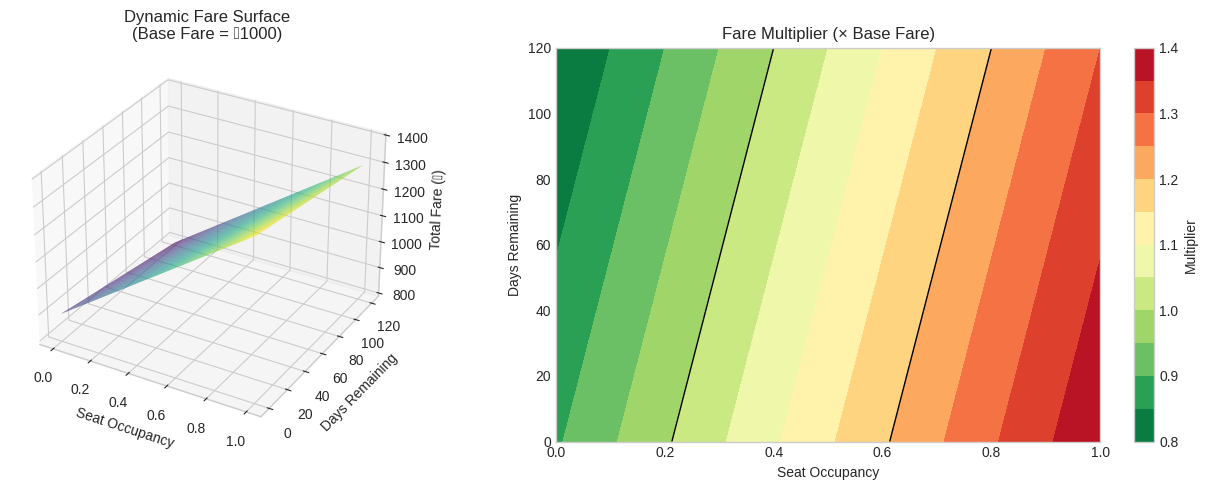

✓ Visualization saved as 'dynamic_fare_surface.png'


In [9]:
# Create 3D surface plot of dynamic fare
fig = plt.figure(figsize=(14, 5))

# Plot 1: 3D Surface of Total Fare
ax1 = fig.add_subplot(121, projection='3d')

# Create meshgrid
occupancy = np.linspace(0, 1, 50)
days = np.linspace(0, 120, 50)
X, Y = np.meshgrid(occupancy, days)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        result = model.calculate_fare(X[i, j], Y[i, j], 1000)
        Z[i, j] = result['total_fare']

ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Seat Occupancy')
ax1.set_ylabel('Days Remaining')
ax1.set_zlabel('Total Fare (₹)')
ax1.set_title('Dynamic Fare Surface\n(Base Fare = ₹1000)')

# Plot 2: Fare multiplier heatmap
ax2 = fig.add_subplot(122)
multipliers = Z / 1000  # Normalize to multiplier

im = ax2.contourf(X, Y, multipliers, levels=np.linspace(0.8, 1.4, 13), cmap='RdYlGn_r')
ax2.set_xlabel('Seat Occupancy')
ax2.set_ylabel('Days Remaining')
ax2.set_title('Fare Multiplier (× Base Fare)')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Multiplier')

# Add contour lines for key thresholds
ax2.contour(X, Y, multipliers, levels=[0.8, 1.0, 1.2, 1.4], colors='black', linewidths=1)

plt.tight_layout()
plt.savefig('dynamic_fare_surface.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'dynamic_fare_surface.png'")

/tmp/ipykernel_918691/3358875702.py:25: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_918691/3358875702.py:26: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('fare_evolution.png', dpi=150, bbox_inches='tight')


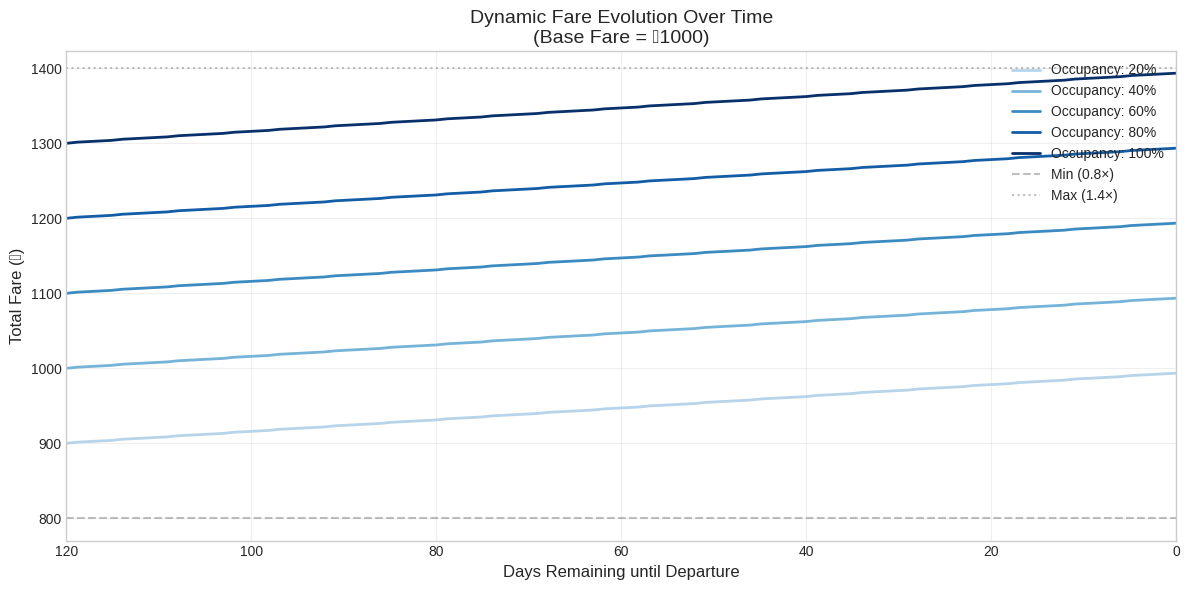

✓ Visualization saved as 'fare_evolution.png'


In [10]:
# Plot: Fare evolution over time for different occupancy levels
fig, ax = plt.subplots(figsize=(12, 6))

days = np.linspace(120, 0, 100)
occupancy_levels = [0.2, 0.4, 0.6, 0.8, 1.0]
colors = plt.cm.Blues(np.linspace(0.3, 1, len(occupancy_levels)))

for occ, color in zip(occupancy_levels, colors):
    fares = []
    for d in days:
        result = model.calculate_fare(occ, int(d), 1000)
        fares.append(result['total_fare'])
    ax.plot(days, fares, label=f'Occupancy: {int(occ*100)}%', color=color, linewidth=2)

ax.axhline(y=800, color='gray', linestyle='--', alpha=0.5, label='Min (0.8×)')
ax.axhline(y=1400, color='gray', linestyle=':', alpha=0.5, label='Max (1.4×)')

ax.set_xlabel('Days Remaining until Departure', fontsize=12)
ax.set_ylabel('Total Fare (₹)', fontsize=12)
ax.set_title('Dynamic Fare Evolution Over Time\n(Base Fare = ₹1000)', fontsize=14)
ax.legend(loc='upper right')
ax.set_xlim(120, 0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fare_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'fare_evolution.png'")

## 6. Batch Processing Pipeline Example

In [11]:
# Create sample data for batch processing
sample_data = pd.DataFrame({
    'train_id': ['TR001', 'TR002', 'TR003', 'TR004', 'TR005'],
    'route': ['Delhi-Mumbai', 'Mumbai-Chennai', 'Kolkata-Delhi', 'Bangalore-Hyderabad', 'Lucknow-Pune'],
    'seat_occupancy': [0.45, 0.78, 0.22, 0.91, 0.65],
    'days_remaining': [45, 12, 100, 5, 30],
    'base_fare': [1500, 2200, 1800, 950, 1350]
})

print("Input Data:")
display(sample_data)
print()

Input Data:


,train_id,route,seat_occupancy,days_remaining,base_fare
0,TR001,Delhi-Mumbai,0.45,45,1500
1,TR002,Mumbai-Chennai,0.78,12,2200
2,TR003,Kolkata-Delhi,0.22,100,1800
3,TR004,Bangalore-Hyderabad,0.91,5,950
4,TR005,Lucknow-Pune,0.65,30,1350


In [12]:
# Apply the pipeline with default parameters
result_df = calculate_dynamic_fare_pipeline(
    sample_data,
    seat_occupancy_col='seat_occupancy',
    days_remaining_col='days_remaining',
    base_fare_col='base_fare'
)

print("Results with Fare Breakdown:")
display(result_df)
print()

Results with Fare Breakdown:


,train_id,route,seat_occupancy,days_remaining,base_fare,dynamic_fare,total_fare,fare_multiplier,time_remaining_pct,adjusted_multiplier
0,TR001,Delhi-Mumbai,0.45,45,1500,425.16,1625.16,1.083,37.5,0.5
1,TR002,Mumbai-Chennai,0.78,12,2200,1043.13,2803.13,1.274,10.0,0.5
2,TR003,Kolkata-Delhi,0.22,100,1800,226.05,1666.05,0.926,83.3,0.5
3,TR004,Bangalore-Hyderabad,0.91,5,950,517.37,1277.37,1.345,4.2,0.5
4,TR005,Lucknow-Pune,0.65,30,1350,533.42,1613.42,1.195,25.0,0.5


In [13]:
# Apply the pipeline with adjustments (e.g., festival week)
result_df_adjusted = calculate_dynamic_fare_pipeline(
    sample_data,
    seat_occupancy_col='seat_occupancy',
    days_remaining_col='days_remaining',
    base_fare_col='base_fare',
    is_festival_week=True  # Festival week adjustment
)

print("Results with Festival Week Adjustment (+25% Multiplier):")
display(result_df_adjusted)

Results with Festival Week Adjustment (+25% Multiplier):


,train_id,route,seat_occupancy,days_remaining,base_fare,dynamic_fare,total_fare,fare_multiplier,time_remaining_pct,adjusted_multiplier
0,TR001,Delhi-Mumbai,0.45,45,1500,531.45,1731.45,1.154,37.5,0.625
1,TR002,Mumbai-Chennai,0.78,12,2200,1303.91,3063.91,1.393,10.0,0.625
2,TR003,Kolkata-Delhi,0.22,100,1800,282.56,1722.56,0.957,83.3,0.625
3,TR004,Bangalore-Hyderabad,0.91,5,950,646.72,1330.00,1.400,4.2,0.625
4,TR005,Lucknow-Pune,0.65,30,1350,666.77,1746.77,1.294,25.0,0.625


## 7. Model Fairness Verification

Singh et al. (2023) proved their model is fair - later customers pay the same or more:

```
DynamicFare(S, T) >= DynamicFare(S - 1, T)     # More occupied = higher fare
DynamicFare(S, T) >= DynamicFare(S, T + 1)    # Less time = higher fare
DynamicFare(S, T) >= DynamicFare(S - 1, T + 1) # Combined effect
```

In [14]:
# Verify model fairness properties
print("=" * 60)
print("Model Fairness Verification")
print("=" * 60)

def verify_fairness(model, base_occupancy=0.5, days=60, base_fare=1000):
    """Verify fairness properties of the model."""
    
    # Property 1: Higher occupancy = higher fare
    fare_lower_occ = model.calculate_fare(base_occupancy - 0.01, days, base_fare)['total_fare']
    fare_higher_occ = model.calculate_fare(base_occupancy, days, base_fare)['total_fare']
    prop1 = fare_higher_occ >= fare_lower_occ
    
    # Property 2: Less time = higher fare
    fare_more_time = model.calculate_fare(base_occupancy, days + 1, base_fare)['total_fare']
    fare_less_time = model.calculate_fare(base_occupancy, days, base_fare)['total_fare']
    prop2 = fare_less_time >= fare_more_time
    
    # Property 3: Combined (higher occ + less time)
    fare_both = model.calculate_fare(base_occupancy, days, base_fare)['total_fare']
    fare_neither = model.calculate_fare(base_occupancy - 0.01, days + 1, base_fare)['total_fare']
    prop3 = fare_both >= fare_neither
    
    return prop1, prop2, prop3


# Test across different scenarios
test_cases = [
    (0.3, 90, 1000),
    (0.5, 60, 1000),
    (0.7, 30, 1000),
    (0.9, 10, 1000),
]

print(f"{'Occupancy':>10} {'Days':>5} {'Prop 1':>8} {'Prop 2':>8} {'Prop 3':>8}")
print("-" * 50)

all_passed = True
for occ, days, fare in test_cases:
    p1, p2, p3 = verify_fairness(model, occ, days, fare)
    status = "✓" if (p1 and p2 and p3) else "✗"
    all_passed = all_passed and p1 and p2 and p3
    print(f"{occ*100:>9.0f}% {days:>5} {str(p1):>8} {str(p2):>8} {str(p3):>8} {status}")

print()
if all_passed:
    print("✓ All fairness properties verified!")
else:
    print("✗ Some fairness properties failed (may be due to fare capping)")

Model Fairness Verification
 Occupancy  Days   Prop 1   Prop 2   Prop 3
--------------------------------------------------
       30%    90     True     True     True ✓
       50%    60     True     True     True ✓
       70%    30     True     True     True ✓
       90%    10     True     True     True ✓

✓ All fairness properties verified!


## 9. Load Vande Bharat Data

In [15]:
# Load Vande Bharat dataset
df = pd.read_csv('VandeBharat_Complete_Data.csv', skiprows=1)

# Clean occupancy columns (remove '%' and convert to float)
def clean_occ(val):
    if pd.isna(val):
        return np.nan
    return float(str(val).replace('%', ''))

occ_cols = [col for col in df.columns if 'Occ' in col and '%' in col]
for col in occ_cols:
    df[col] = df[col].apply(clean_occ)

print(f"Loaded {len(df)} Vande Bharat trains")
print(f"Columns: {len(df.columns)}")
print(f"\nSample data:")
df[['Sr No', 'From (Origin)', 'To (Destination)', 'CC Fare (INR)', 'EC Fare (INR)', 'CC UP Avg Occ %', 'CC DN Avg Occ %']].head()

Loaded 82 Vande Bharat trains
Columns: 113

Sample data:


,Sr No,From (Origin),To (Destination),CC Fare (INR),EC Fare (INR),CC UP Avg Occ %,CC DN Avg Occ %
0,1,Varanasi,New Delhi,1780,3335,84.0,78.0
1,2,New Delhi,Sri Mata Vaishno Devi Katra,1635,3030,72.0,61.0
2,3,Mumbai Central,Gandhinagar Capital,1475,2750,73.0,59.0
3,4,New Delhi,Amb Andaura,1125,2125,62.0,66.0
4,5,Chennai Central,Mysuru,850,1585,60.0,68.0


## 10. Chair Car (CC) Analysis

In [16]:
# Chair Car Analysis
# Use average occupancy and base fare for CC

def calculate_cc_dynamic_pricing(df, model):
    """Calculate dynamic pricing for Chair Car class."""
    results = []
    
    for idx, row in df.iterrows():
        # CC Up direction
        cc_up_occ = row['CC UP Avg Occ %'] / 100
        cc_dn_occ = row['CC DN Avg Occ %'] / 100
        base_fare = row['CC Fare (INR)']
        seats = row['CC Seats']
        
        # Use average of UP and DN occupancy for a single journey
        avg_occ = (cc_up_occ + cc_dn_occ) / 2
        
        # Assume 60 days average for booking window (mid-point of 120)
        days_remaining = 60
        
        fare_result = model.calculate_fare(avg_occ, days_remaining, base_fare)
        
        # Current revenue (assuming 100% occupancy for max potential)
        current_revenue = base_fare * seats * avg_occ
        dynamic_revenue = fare_result['total_fare'] * seats
        max_revenue = base_fare * 1.4 * seats  # Max fare cap
        
        results.append({
            'Train': f"{row['From (Origin)']} -> {row['To (Destination)']}",
            'Base Fare': base_fare,
            'Avg Occupancy': round(avg_occ * 100, 1),
            'Current Fare': fare_result['base_fare'],
            'Dynamic Fare': fare_result['total_fare'],
            'Fare Multiplier': fare_result['fare_multiplier'],
            'Current Revenue': current_revenue,
            'Dynamic Revenue': dynamic_revenue,
            'Revenue Gain': dynamic_revenue - current_revenue,
            'Gain %': ((dynamic_revenue - current_revenue) / current_revenue) * 100
        })
    
    return pd.DataFrame(results)

# Run CC analysis
cc_model = DynamicPricingModel(weight=DEFAULT_WEIGHT, multiplier=DEFAULT_MULTIPLIER)
cc_results = calculate_cc_dynamic_pricing(df, cc_model)

print("=" * 80)
print("CHAIR CAR (CC) DYNAMIC PRICING ANALYSIS")
print("=" * 80)
print(f"\nModel Parameters: Weight={DEFAULT_WEIGHT}, Multiplier={DEFAULT_MULTIPLIER}")
print(f"\nAverage Fare Multiplier: {cc_results['Fare Multiplier'].mean():.3f}×")
print(f"Min Fare Multiplier: {cc_results['Fare Multiplier'].min():.3f}×")
print(f"Max Fare Multiplier: {cc_results['Fare Multiplier'].max():.3f}×")
print(f"\nTotal Current Revenue: ₹{cc_results['Current Revenue'].sum():,.0f}")
print(f"Total Dynamic Revenue: ₹{cc_results['Dynamic Revenue'].sum():,.0f}")
print(f"Total Revenue Gain: ₹{cc_results['Revenue Gain'].sum():,.0f}")
print(f"Average Gain %: {cc_results['Gain %'].mean():.1f}%")

CHAIR CAR (CC) DYNAMIC PRICING ANALYSIS

Model Parameters: Weight=0.187, Multiplier=0.5

Average Fare Multiplier: 1.205×
Min Fare Multiplier: 1.124×
Max Fare Multiplier: 1.282×

Total Current Revenue: ₹50,523,674
Total Dynamic Revenue: ₹85,009,298
Total Revenue Gain: ₹34,485,625
Average Gain %: 69.4%


In [17]:
# Display CC results sample
print("\nTop 10 trains by Revenue Gain (CC):")
cc_results_sorted = cc_results.sort_values('Revenue Gain', ascending=False)
display(cc_results_sorted.head(10)[['Train', 'Base Fare', 'Avg Occupancy', 'Current Fare', 'Dynamic Fare', 'Fare Multiplier', 'Revenue Gain', 'Gain %']])


Top 10 trains by Revenue Gain (CC):


,Train,Base Fare,Avg Occupancy,Current Fare,Dynamic Fare,Fare Multiplier,Revenue Gain,Gain %
81,Howrah -> Kamakhya,2435,73.0,2435,2950.61,1.212,844603.2,65.993080
34,Varanasi -> New Delhi (2nd),1825,67.5,1825,2161.26,1.184,724920.3,75.444749
45,H. Nizamuddin -> Khajuraho,1850,69.5,1850,2209.36,1.194,720415.8,71.834338
1,New Delhi -> Sri Mata Vaishno Devi Katra,1635,66.5,1635,1928.07,1.179,655820.1,77.330482
0,Varanasi -> New Delhi,1780,81.0,1780,2228.12,1.252,613329.6,54.537384
18,Indore -> Nagpur,1355,55.5,1355,1523.36,1.124,601641.3,102.567734
38,Sri Mata Vaishno Devi Katra -> New Delhi (2nd),1635,75.5,1635,2001.65,1.224,598435.5,62.152419
2,Mumbai Central -> Gandhinagar Capital,1475,66.0,1475,1735.71,1.177,594523.8,78.295840
51,Meerut City -> Varanasi,1460,67.0,1460,1725.36,1.182,582784.8,76.381108
42,Secunderabad -> Visakhapatnam,1480,72.0,1480,1785.99,1.207,561904.2,67.604167


## 11. Executive Chair (EC) Analysis

In [18]:
# Executive Chair Analysis
def calculate_ec_dynamic_pricing(df, model):
    """Calculate dynamic pricing for Executive Chair class."""
    results = []
    
    for idx, row in df.iterrows():
        # EC Up and Down occupancy
        ec_up_occ = row['EC UP Avg Occ %'] / 100
        ec_dn_occ = row['EC DN Avg Occ %'] / 100
        base_fare = row['EC Fare (INR)']
        seats = row['EC Seats']
        
        # Average occupancy
        avg_occ = (ec_up_occ + ec_dn_occ) / 2
        
        # Days remaining
        days_remaining = 60
        
        fare_result = model.calculate_fare(avg_occ, days_remaining, base_fare)
        
        # Revenue calculations
        current_revenue = base_fare * seats * avg_occ
        dynamic_revenue = fare_result['total_fare'] * seats
        
        results.append({
            'Train': f"{row['From (Origin)']} -> {row['To (Destination)']}",
            'Base Fare': base_fare,
            'Avg Occupancy': round(avg_occ * 100, 1),
            'Current Fare': fare_result['base_fare'],
            'Dynamic Fare': fare_result['total_fare'],
            'Fare Multiplier': fare_result['fare_multiplier'],
            'Current Revenue': current_revenue,
            'Dynamic Revenue': dynamic_revenue,
            'Revenue Gain': dynamic_revenue - current_revenue,
            'Gain %': ((dynamic_revenue - current_revenue) / current_revenue) * 100
        })
    
    return pd.DataFrame(results)

# Run EC analysis
ec_model = DynamicPricingModel(weight=DEFAULT_WEIGHT, multiplier=DEFAULT_MULTIPLIER)
ec_results = calculate_ec_dynamic_pricing(df, ec_model)

print("=" * 80)
print("EXECUTIVE CHAIR (EC) DYNAMIC PRICING ANALYSIS")
print("=" * 80)
print(f"\nModel Parameters: Weight={DEFAULT_WEIGHT}, Multiplier={DEFAULT_MULTIPLIER}")
print(f"\nAverage Fare Multiplier: {ec_results['Fare Multiplier'].mean():.3f}×")
print(f"Min Fare Multiplier: {ec_results['Fare Multiplier'].min():.3f}×")
print(f"Max Fare Multiplier: {ec_results['Fare Multiplier'].max():.3f}×")
print(f"\nTotal Current Revenue: ₹{ec_results['Current Revenue'].sum():,.0f}")
print(f"Total Dynamic Revenue: ₹{ec_results['Dynamic Revenue'].sum():,.0f}")
print(f"Total Revenue Gain: ₹{ec_results['Revenue Gain'].sum():,.0f}")
print(f"Average Gain %: {ec_results['Gain %'].mean():.1f}%")

EXECUTIVE CHAIR (EC) DYNAMIC PRICING ANALYSIS

Model Parameters: Weight=0.187, Multiplier=0.5

Average Fare Multiplier: 1.172×
Min Fare Multiplier: 1.102×
Max Fare Multiplier: 1.242×

Total Current Revenue: ₹11,522,564
Total Dynamic Revenue: ₹20,851,756
Total Revenue Gain: ₹9,329,192
Average Gain %: 81.9%


In [19]:
# Display EC results sample
print("\nTop 10 trains by Revenue Gain (EC):")
ec_results_sorted = ec_results.sort_values('Revenue Gain', ascending=False)
display(ec_results_sorted.head(10)[['Train', 'Base Fare', 'Avg Occupancy', 'Current Fare', 'Dynamic Fare', 'Fare Multiplier', 'Revenue Gain', 'Gain %']])


Top 10 trains by Revenue Gain (EC):


,Train,Base Fare,Avg Occupancy,Current Fare,Dynamic Fare,Fare Multiplier,Revenue Gain,Gain %
81,Howrah -> Kamakhya,3855,65.5,3855,4526.73,1.174,384327.36,79.274661
45,H. Nizamuddin -> Khajuraho,3445,54.5,3445,3855.82,1.119,205742.68,105.367172
34,Varanasi -> New Delhi (2nd),3350,57.0,3350,3791.36,1.132,195713.44,98.552501
0,Varanasi -> New Delhi,3335,60.5,3335,3832.75,1.149,188767.80,89.958740
1,New Delhi -> Sri Mata Vaishno Devi Katra,3030,52.5,3030,3361.03,1.109,184109.12,111.285871
38,Sri Mata Vaishno Devi Katra -> New Delhi (2nd),3030,58.5,3030,3451.93,1.139,174655.52,94.743731
51,Meerut City -> Varanasi,2720,58.0,2720,3091.96,1.137,157493.44,95.991379
37,CSMT Mumbai -> Nanded,2580,53.5,2580,2874.77,1.114,155424.88,108.271390
54,Varanasi -> Deoghar,2495,53.5,2495,2780.05,1.114,150303.40,108.270747
42,Secunderabad -> Visakhapatnam,2755,68.5,2755,3276.38,1.189,144477.32,73.612940


## 12. CC vs EC Comparison

In [20]:
# Combined comparison
print("=" * 80)
print("COMBINED REVENUE ANALYSIS (CC + EC)")
print("=" * 80)

total_current = cc_results['Current Revenue'].sum() + ec_results['Current Revenue'].sum()
total_dynamic = cc_results['Dynamic Revenue'].sum() + ec_results['Dynamic Revenue'].sum()
total_gain = total_dynamic - total_current
gain_pct = (total_gain / total_current) * 100

print(f"\n{'Class':<15} {'Current Revenue':>18} {'Dynamic Revenue':>18} {'Gain':>18} {'Gain %':>10}")
print("-" * 80)
print(f"{'Chair Car':<15} ₹{cc_results['Current Revenue'].sum():>15,.0f} ₹{cc_results['Dynamic Revenue'].sum():>15,.0f} ₹{cc_results['Revenue Gain'].sum():>15,.0f} {cc_results['Gain %'].mean():>9.1f}%")
print(f"{'Exec Chair':<15} ₹{ec_results['Current Revenue'].sum():>15,.0f} ₹{ec_results['Dynamic Revenue'].sum():>15,.0f} ₹{ec_results['Revenue Gain'].sum():>15,.0f} {ec_results['Gain %'].mean():>9.1f}%")
print("-" * 80)
print(f"{'TOTAL':<15} ₹{total_current:>15,.0f} ₹{total_dynamic:>15,.0f} ₹{total_gain:>15,.0f} {gain_pct:>9.1f}%")

COMBINED REVENUE ANALYSIS (CC + EC)

Class              Current Revenue    Dynamic Revenue               Gain     Gain %
--------------------------------------------------------------------------------
Chair Car       ₹     50,523,674 ₹     85,009,298 ₹     34,485,625      69.4%
Exec Chair      ₹     11,522,564 ₹     20,851,756 ₹      9,329,192      81.9%
--------------------------------------------------------------------------------
TOTAL           ₹     62,046,238 ₹    105,861,054 ₹     43,814,816      70.6%


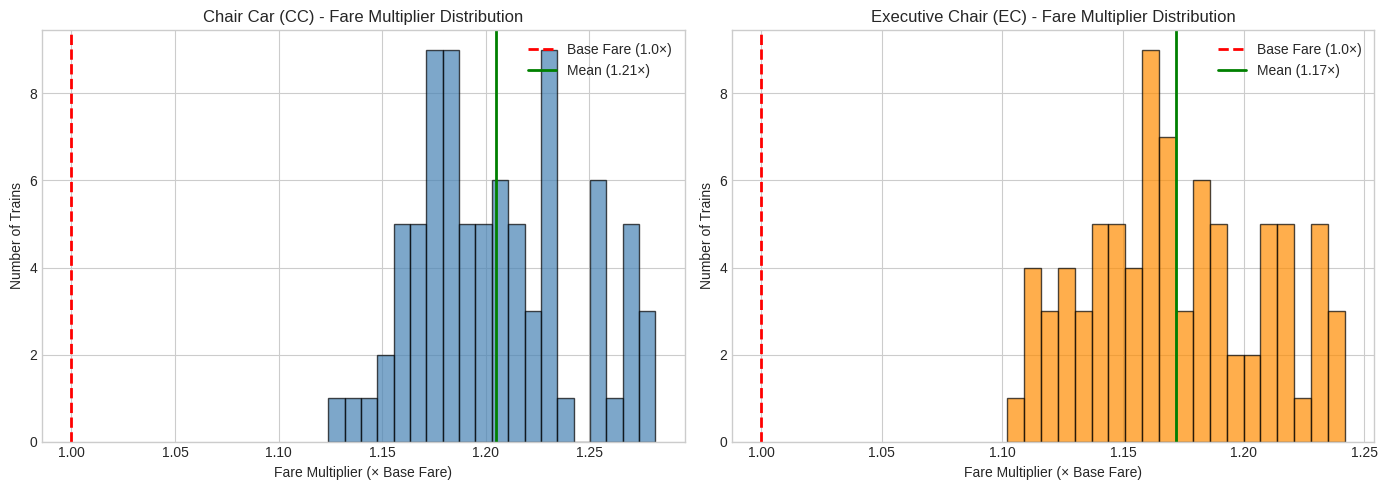

✓ Visualization saved as 'vandebharat_fare_distribution.png'


In [21]:
# Visualization: Fare multiplier distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CC Distribution
axes[0].hist(cc_results['Fare Multiplier'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Base Fare (1.0×)')
axes[0].axvline(x=cc_results['Fare Multiplier'].mean(), color='green', linestyle='-', linewidth=2, label=f'Mean ({cc_results["Fare Multiplier"].mean():.2f}×)')
axes[0].set_xlabel('Fare Multiplier (× Base Fare)')
axes[0].set_ylabel('Number of Trains')
axes[0].set_title('Chair Car (CC) - Fare Multiplier Distribution')
axes[0].legend()

# EC Distribution
axes[1].hist(ec_results['Fare Multiplier'], bins=20, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Base Fare (1.0×)')
axes[1].axvline(x=ec_results['Fare Multiplier'].mean(), color='green', linestyle='-', linewidth=2, label=f'Mean ({ec_results["Fare Multiplier"].mean():.2f}×)')
axes[1].set_xlabel('Fare Multiplier (× Base Fare)')
axes[1].set_ylabel('Number of Trains')
axes[1].set_title('Executive Chair (EC) - Fare Multiplier Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('vandebharat_fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'vandebharat_fare_distribution.png'")

/tmp/ipykernel_918691/2300451399.py:22: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_918691/2300451399.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('vandebharat_revenue_gain.png', dpi=150, bbox_inches='tight')
/home/srirang/code/homework/SCA_Sem2_PGDBA/project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


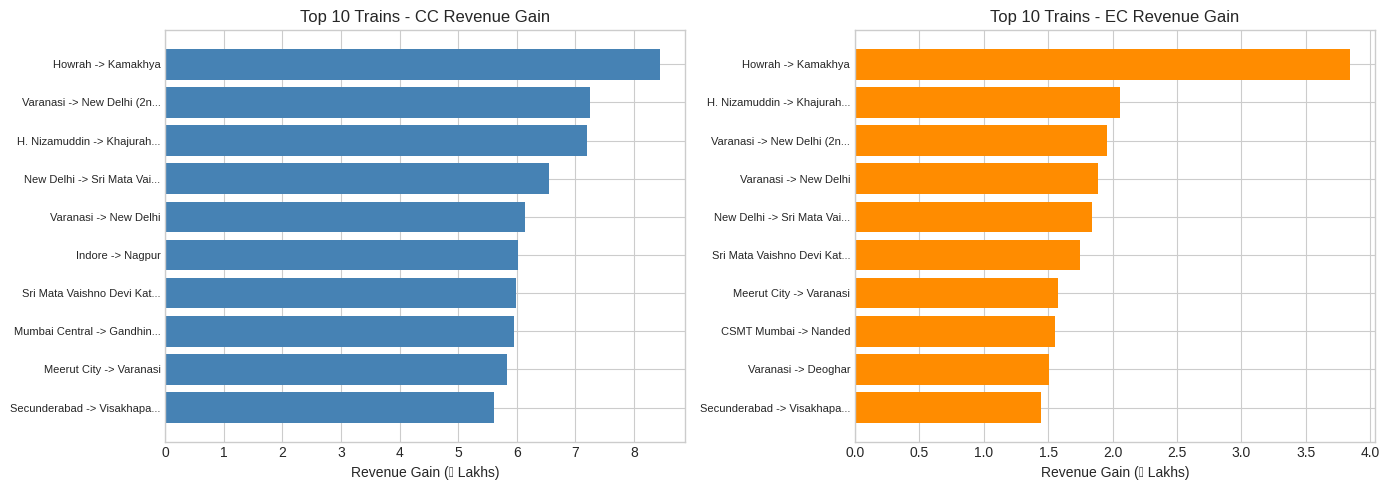

✓ Visualization saved as 'vandebharat_revenue_gain.png'


In [22]:
# Visualization: Revenue comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 trains by gain - CC
top_cc = cc_results_sorted.head(10)
axes[0].barh(range(10), top_cc['Revenue Gain'] / 100000, color='steelblue')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([t[:25] + '...' if len(t) > 25 else t for t in top_cc['Train']], fontsize=8)
axes[0].set_xlabel('Revenue Gain (₹ Lakhs)')
axes[0].set_title('Top 10 Trains - CC Revenue Gain')
axes[0].invert_yaxis()

# Top 10 trains by gain - EC
top_ec = ec_results_sorted.head(10)
axes[1].barh(range(10), top_ec['Revenue Gain'] / 100000, color='darkorange')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([t[:25] + '...' if len(t) > 25 else t for t in top_ec['Train']], fontsize=8)
axes[1].set_xlabel('Revenue Gain (₹ Lakhs)')
axes[1].set_title('Top 10 Trains - EC Revenue Gain')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('vandebharat_revenue_gain.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as 'vandebharat_revenue_gain.png'")

## 13. Summary - Vande Bharat Analysis

In [23]:
# Final Summary
print("=" * 80)
print("VANDE BHARAT DYNAMIC PRICING SUMMARY")
print("=" * 80)
print(f"\nDataset: {len(df)} Vande Bharat trains")
print(f"Analysis Period: March 31 - April 19 (20 days)")
print(f"\nModel Parameters:")
print(f"  - Weight (w): {DEFAULT_WEIGHT}")
print(f"  - Multiplier (M): {DEFAULT_MULTIPLIER}")
print(f"  - Max Booking Days: {MAX_BOOKING_DAYS}")
print(f"  - Fare Range: {FARE_MIN_MULTIPLIER}× to {FARE_MAX_MULTIPLIER}× base fare")
print(f"\n{'='*80}")
print("REVENUE IMPACT:")
print(f"{'='*80}")
print(f"\nChair Car (CC):")
print(f"  - Current Avg Fare: ₹{cc_results['Current Fare'].mean():,.0f}")
print(f"  - Dynamic Avg Fare: ₹{cc_results['Dynamic Fare'].mean():,.0f}")
print(f"  - Avg Fare Multiplier: {cc_results['Fare Multiplier'].mean():.3f}×")
print(f"  - Total Revenue Gain: ₹{cc_results['Revenue Gain'].sum():,.0f} ({cc_results['Gain %'].mean():.1f}%)")
print(f"\nExecutive Chair (EC):")
print(f"  - Current Avg Fare: ₹{ec_results['Current Fare'].mean():,.0f}")
print(f"  - Dynamic Avg Fare: ₹{ec_results['Dynamic Fare'].mean():,.0f}")
print(f"  - Avg Fare Multiplier: {ec_results['Fare Multiplier'].mean():.3f}×")
print(f"  - Total Revenue Gain: ₹{ec_results['Revenue Gain'].sum():,.0f} ({ec_results['Gain %'].mean():.1f}%)")
print(f"\n{'='*80}")
print(f"TOTAL COMBINED IMPACT:")
print(f"{'='*80}")
print(f"  Current Total Revenue: ₹{total_current:,.0f}")
print(f"  Dynamic Total Revenue: ₹{total_dynamic:,.0f}")
print(f"  Net Revenue Gain: ₹{total_gain:,.0f}")
print(f"  Gain Percentage: {gain_pct:.1f}%")
print("\n" + "=" * 80)

VANDE BHARAT DYNAMIC PRICING SUMMARY

Dataset: 82 Vande Bharat trains
Analysis Period: March 31 - April 19 (20 days)

Model Parameters:
  - Weight (w): 0.187
  - Multiplier (M): 0.5
  - Max Booking Days: 120
  - Fare Range: 0.8× to 1.4× base fare

REVENUE IMPACT:

Chair Car (CC):
  - Current Avg Fare: ₹1,105
  - Dynamic Avg Fare: ₹1,332
  - Avg Fare Multiplier: 1.205×
  - Total Revenue Gain: ₹34,485,625 (69.4%)

Executive Chair (EC):
  - Current Avg Fare: ₹2,050
  - Dynamic Avg Fare: ₹2,398
  - Avg Fare Multiplier: 1.172×
  - Total Revenue Gain: ₹9,329,192 (81.9%)

TOTAL COMBINED IMPACT:
  Current Total Revenue: ₹62,046,238
  Dynamic Total Revenue: ₹105,861,054
  Net Revenue Gain: ₹43,814,816
  Gain Percentage: 70.6%

